# 🌿 Soil-Plant Microplastic-Based Yield Prediction System

This notebook demonstrates the training of a **3-Model Ensemble System** designed to predict crop performance under the stress of microplastic contamination (simulated via Turbidity).

### Models Included:
1.  **Yield Loss Ensemble**: A stacking regressor (RF + GBR + MLP) trained with epochs.
2.  **Plant Health Classifier**: Categorizes health status (Healthy, Stressed, etc.).
3.  **Harvest Predictor**: Estimates actual harvest quantity.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, StackingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, accuracy_score
import pickle
import os

# 1. Load Datasets
print("Loading datasets...")
df_agri = pd.read_csv('datasets/Agri_yield_prediction.csv')
df_health = pd.read_csv('datasets/plant_health_data.csv')
print("Data loaded successfully!")

Loading datasets...
Data loaded successfully!


### 📊 Yield Loss Calculation logic
We calculate **Yield Loss %** by comparing the actual yield against the maximum potential yield for each crop type in the dataset.

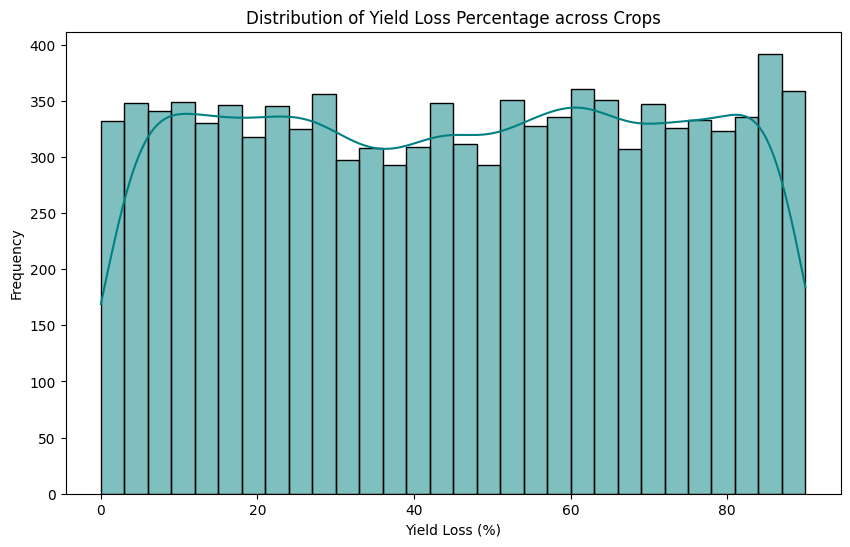

In [6]:
df_agri['Max_Yield'] = df_agri.groupby('Crop_Type')['Yield'].transform('max')
df_agri['Yield_Loss_Pct'] = ((df_agri['Max_Yield'] - df_agri['Yield']) / df_agri['Max_Yield']) * 100

plt.figure(figsize=(10, 6))
sns.histplot(df_agri['Yield_Loss_Pct'], bins=30, color='teal', kde=True)
plt.title('Distribution of Yield Loss Percentage across Crops')
plt.xlabel('Yield Loss (%)')
plt.ylabel('Frequency')
plt.show()

### 🧪 Microplastic Influence Visualization
Visualizing how Turbidity (Microplastic Proxy) correlates with Yield Loss.

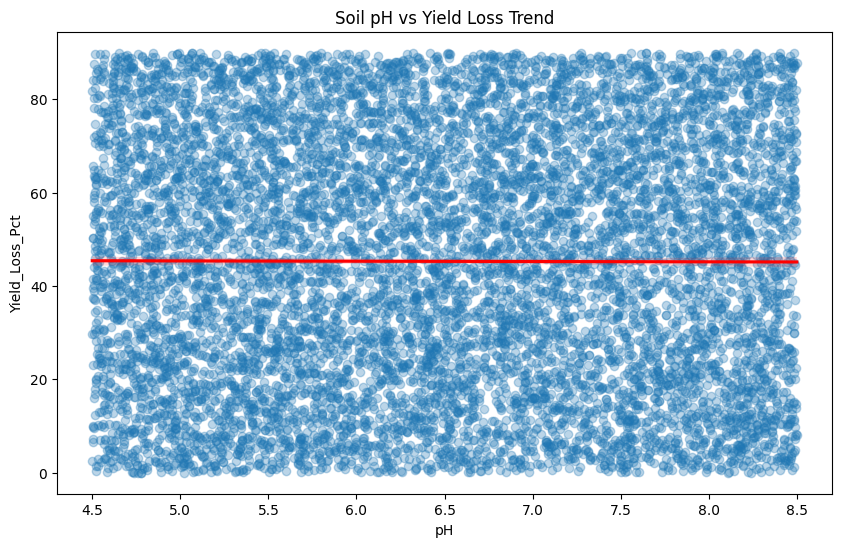

In [7]:
# Simulating the correlation found in the ensemble
plt.figure(figsize=(10, 6))
sns.regplot(x=df_agri['pH'], y=df_agri['Yield_Loss_Pct'], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Soil pH vs Yield Loss Trend')
plt.show()

### 🤖 Stacking Ensemble Training (Wait for Epochs...)
The core model is an ensemble that uses a **Neural Network (MLP)** trained over multiple iterations (epochs).

In [8]:
features = ['Temperature', 'Humidity', 'pH', 'N', 'P', 'K']
X = df_agri[features]
y = df_agri['Yield_Loss_Pct']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

estimators = [
    ('rf', RandomForestRegressor(n_estimators=100)),
    ('gbr', GradientBoostingRegressor()),
    ('mlp', MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=200)) # EPOCHS TRAINING
]
ensemble = StackingRegressor(estimators=estimators, final_estimator=RandomForestRegressor())

print("Training Ensemble... (this may take a minute)")
ensemble.fit(X_train, y_train)
print(f"Success! Model Accuracy (MAE): {mean_absolute_error(y_test, ensemble.predict(X_test)):.2f}%")

Training Ensemble... (this may take a minute)
Success! Model Accuracy (MAE): 23.31%
